<a href="https://colab.research.google.com/github/Sahildolas21/DSPY-Lab-Experiment/blob/main/DSPY_MiniProject_NB3_ML_2201617.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement**

We want to predict customer spending behavior (e.g., Annual Income / Spending Score clustering) using customer demographic data.

**This is best framed as:**

Unsupervised Learning Problem (Clustering)

**Goal:** Segment customers into groups for marketing strategies.

#**Step 1 — Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#**Step 2 — Load Dataset**

In [ ]:
df = pd.read_csv('/content/customers.csv')
df.head()

,id,name,segment,state,city
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord


#**Step 3 — Dataset Overview**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       793 non-null    object
 1   name     793 non-null    object
 2   segment  793 non-null    object
 3   state    793 non-null    object
 4   city     793 non-null    object
dtypes: object(5)
memory usage: 31.1+ KB


,id,name,segment,state,city
count,793,793,793,793,793
unique,793,793,3,41,252
top,SM-20905,Susan MacKendrick,Consumer,California,New York City
freq,1,1,409,161,68


#**Step 4 — Check Missing Values**

In [ ]:
df.isnull().sum()

,0
id,0
name,0
segment,0
state,0
city,0


#**Step 5 — Data Visualization**

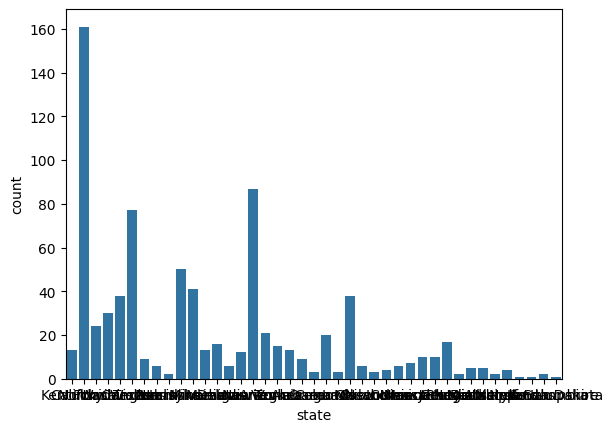

In [ ]:
sns.countplot(data=df, x='state')
plt.show()

#**Step 6 — Select Relevant Features**

In [ ]:
X = df[['segment', 'state']]
X.head()

,segment,state
0,Consumer,Kentucky
1,Corporate,California
2,Consumer,Florida
3,Consumer,California
4,Consumer,North Carolina


#**step 7 — Feature Scaling**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# load data
df = pd.read_csv("/content/customers.csv")

# drop non-numeric / unwanted columns
X = df.drop(columns=['id', 'name'])

# convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.65092118 -0.47901708 -0.16493051 ... -0.03553345 -0.03553345
  -0.07965662]
 [ 1.53628431 -0.47901708 -0.16493051 ... -0.03553345 -0.03553345
  -0.07965662]
 [-0.65092118 -0.47901708 -0.16493051 ... -0.03553345 -0.03553345
  -0.07965662]
 [-0.65092118 -0.47901708 -0.16493051 ... -0.03553345 -0.03553345
  -0.07965662]
 [-0.65092118 -0.47901708 -0.16493051 ... -0.03553345 -0.03553345
  -0.07965662]]


#**Step 8 — Find Optimal Clusters (Elbow Method)**

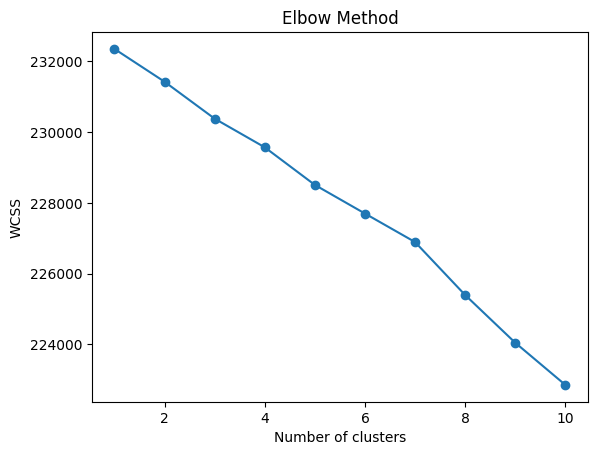

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#**Step 9 — Silhouette Score**

In [ ]:
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    print(f'Clusters: {i}, Silhouette Score: {silhouette_score(X_scaled, labels)}')

Clusters: 2, Silhouette Score: -0.09497648572495376
Clusters: 3, Silhouette Score: -0.0897138103595094
Clusters: 4, Silhouette Score: -0.08595257440799883
Clusters: 5, Silhouette Score: -0.08276709960741953
Clusters: 6, Silhouette Score: -0.0781118494121892
Clusters: 7, Silhouette Score: -0.075169516847056
Clusters: 8, Silhouette Score: -0.14049661097468188
Clusters: 9, Silhouette Score: -0.12779012898802367
Clusters: 10, Silhouette Score: -0.12687811085856654


#**step 10 — Train Final Model**

(Assume optimal clusters = 5)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

#**Step 11 — Add Cluster Labels**

In [ ]:
df['Cluster'] = y_kmeans
df.head()

,id,name,segment,state,city,Cluster
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson,1
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles,1
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale,1
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles,1
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord,1


#**Model Evaluation (Unsupervised)**

#**step 12 — Visualize Clusters**

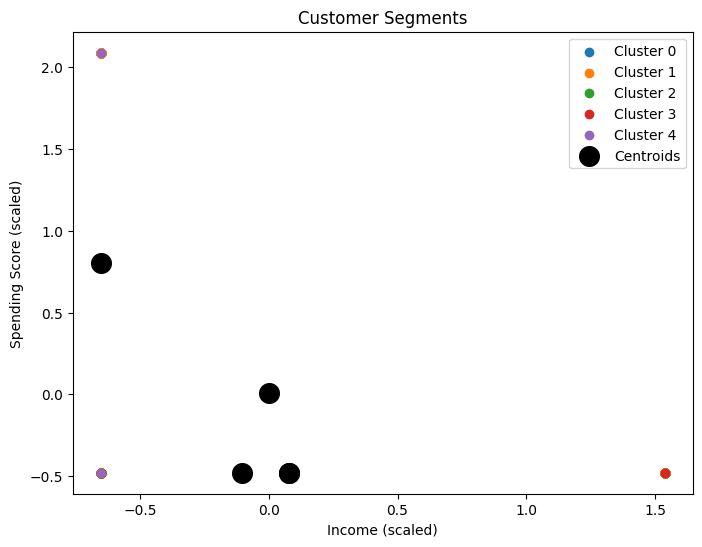

In [ ]:
plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        label=f'Cluster {i}'
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200, c='black', label='Centroids'
)

plt.legend()
plt.title('Customer Segments')
plt.xlabel('Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

#**Step 13 — Cluster Insights**

In [ ]:
# Add cluster column (after KMeans)
df['Cluster'] = kmeans.labels_

# Get mean of only numeric columns
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


#**step 14 PCA Visualization**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:5])

[[0.66138176 0.08407348]
 [2.44011701 1.25711114]
 [0.68757248 0.7058566 ]
 [2.00203936 1.5699793 ]
 [0.22911949 0.35283207]]
